In [1]:
import os
import zipfile

zip_path = "/content/archive (8).zip"

if os.path.exists(zip_path):
    print("ZIP file found!")
    print(f"File size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

    with zipfile.ZipFile(zip_path, "r") as z:
        print("\nFirst 20 files inside the ZIP:")
        for name in z.namelist()[:20]:
            print(name)
else:
    print("ZIP file not found. Check the filename.")

ZIP file found!
File size: 21.00 MB


BadZipFile: File is not a zip file

In [2]:
import os

file_path = "/content/archive (8).zip"

print("File exists:", os.path.exists(file_path))
print("File size:", round(os.path.getsize(file_path) / (1024 * 1024), 2), "MB")

with open(file_path, "rb") as f:
    first_bytes = f.read(300)

print("\nFirst bytes of the file:")
print(first_bytes)

print("\nReadable preview:")
print(first_bytes.decode("utf-8", errors="replace"))

File exists: True
File size: 25.71 MB

First bytes of the file:
b'PK\x03\x04-\x00\x00\x00\x08\x00\x1d\x9bSO\x93\xc4\x19\x10\xff\xff\xff\xff\xff\xff\xff\xff\x10\x00\x14\x00IMDB Dataset.csv\x01\x00\x10\x00\xd5Q\xf2\x03\x00\x00\x00\x007j\x9b\x01\x00\x00\x00\x00\x8c\xbd\xdbz\x1bI\x92&x?O\x11\xe2\xb7\x93$g\x00\x942\xab\xab\xab+kw\xf4Qg\xa6\x8eK\xaaR\x9d}\xe7@8\x00\x17#\xc2\x91q \x04=\xcd^n?G\xbf\xd8\xda\xff\x9b\xb9G\x04\x955\xdf\xd6LW\x89$\x10\xe1\x07;\xdbof\xad\xbf\x0f\xfe\xb8\xe8|\xd3\x87Z\xfe\xeb\xbf\x9d}h|\x11\xb7E\xbf\x97\xff\x91\xffj\x0b\xfd\x88o\xbbb\xef\xba\x02\x1f\n\xb1\xf1\xa5|\xc2\xf5\x85\xdb\xf6\xf2\x91\xa3\xeb7\xfb\xd0\xec\x8a/C\xd7\x17?\x16\x1f\xbe\x15\xfe\x10\xbaX\xfa\xe2\x14\x87\xf3\xaa*\xd6\xbe\xd8\xc7x\xe7\xcbU\xf1i\xefO\x85k}\xd1\x86\xdd\xbe_\x14\xf2\xd0~\x1f\xbaB\xfe\xbf\xff\xea6}u*\x8ex\xf4\xde\x1d\x0e\x1e/:\x86~/\xef]\xfd\x9f\xeb\xb6\xf8\xd3\xff\xd2\xff\x96\x87\x14\xdb\xd0\xca\xdbz\xbe\x98\x8b\xe9\xfav\xd8\xdc\xc9G\x0b\xb7\x8eC\x8fe\x1c'

Readable preview:
PK-    �

In [3]:
import zipfile
import subprocess

zip_path = "/content/archive (8).zip"

print("Python ZIP check:", zipfile.is_zipfile(zip_path))

result = subprocess.run(
    ["unzip", "-t", zip_path],
    capture_output=True,
    text=True
)

print("\nUnzip test output:")
print(result.stdout[-3000:] if result.stdout else result.stderr[-3000:])
print("\nExit code:", result.returncode)

Python ZIP check: True

Unzip test output:
Archive:  /content/archive (8).zip
    testing: IMDB Dataset.csv         OK
No errors detected in compressed data of /content/archive (8).zip.


Exit code: 0


In [4]:
import os
import pandas as pd
import subprocess

zip_path = "/content/archive (8).zip"
extract_path = "/content/imdb_data"

# Extract the dataset
os.makedirs(extract_path, exist_ok=True)

subprocess.run(
    ["unzip", "-o", zip_path, "-d", extract_path],
    check=True,
    capture_output=True,
    text=True
)

# Load the CSV
csv_path = os.path.join(extract_path, "IMDB Dataset.csv")
df = pd.read_csv(csv_path)

print("DATASET LOADED SUCCESSFULLY")
print("=" * 50)
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

DATASET LOADED SUCCESSFULLY
Dataset shape: (50000, 2)

Column names:
['review', 'sentiment']

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


DATASET OVERVIEW
Number of rows: 50000
Number of columns: 2
Duplicate rows: 418

COLUMN DATA TYPES
review       object
sentiment    object
dtype: object

MISSING VALUES
review       0
sentiment    0
dtype: int64

SENTIMENT DISTRIBUTION
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

SENTIMENT PERCENTAGES
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

REVIEW LENGTH STATISTICS
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

WORD COUNT STATISTICS
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64

EXAMPLE POSITIVE REVIEW
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. 

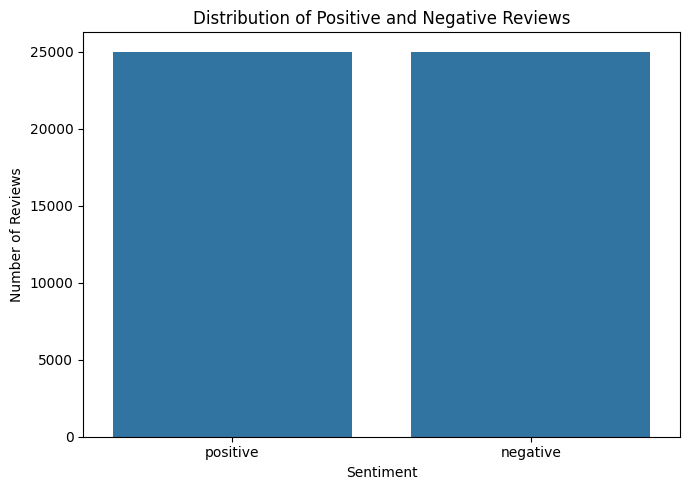

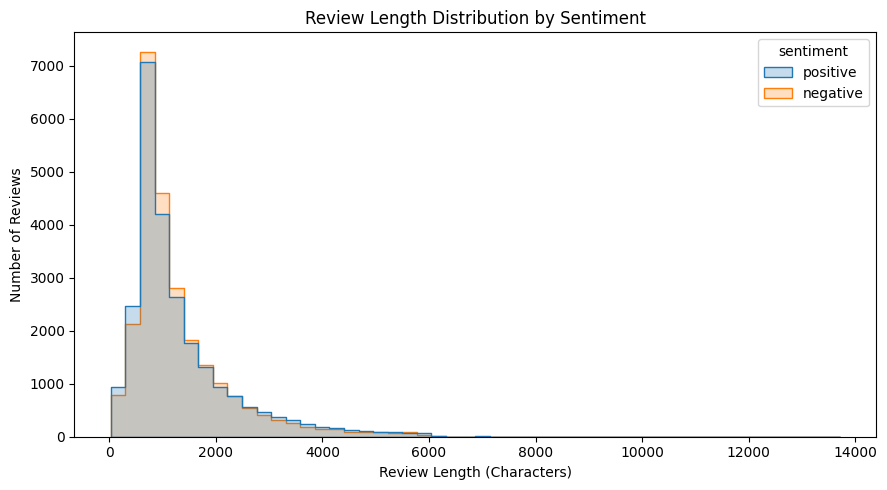

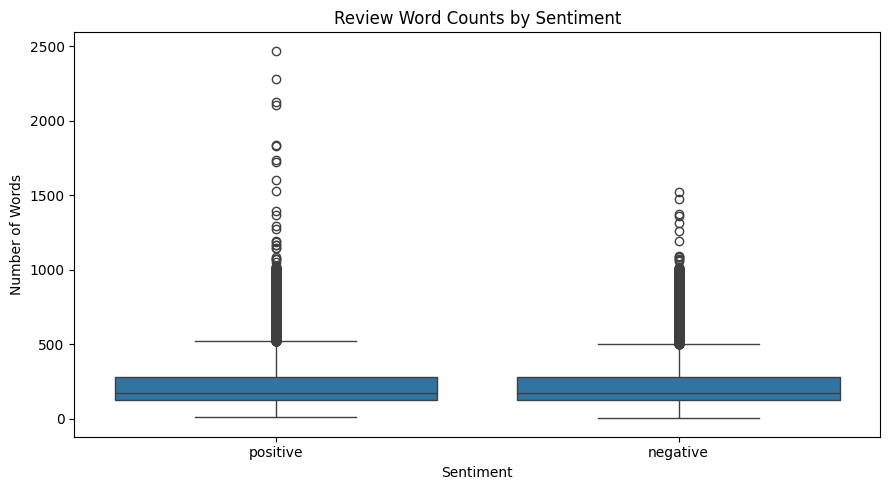

In [5]:
# STEP 5: DATA INSPECTION AND EXPLORATORY DATA ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

print("\nCOLUMN DATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSENTIMENT DISTRIBUTION")
print(df["sentiment"].value_counts())

print("\nSENTIMENT PERCENTAGES")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

print("\nREVIEW LENGTH STATISTICS")
df["review_length"] = df["review"].astype(str).apply(len)
print(df["review_length"].describe())

print("\nWORD COUNT STATISTICS")
df["word_count"] = df["review"].astype(str).apply(
    lambda text: len(text.split())
)
print(df["word_count"].describe())

print("\nEXAMPLE POSITIVE REVIEW")
print(df[df["sentiment"] == "positive"]["review"].iloc[0][:500])

print("\nEXAMPLE NEGATIVE REVIEW")
print(df[df["sentiment"] == "negative"]["review"].iloc[0][:500])

# VISUALIZATION 1: SENTIMENT DISTRIBUTION
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sentiment")
plt.title("Distribution of Positive and Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# VISUALIZATION 2: REVIEW LENGTH DISTRIBUTION
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x="review_length",
    hue="sentiment",
    bins=50,
    element="step",
    stat="count"
)
plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# VISUALIZATION 3: WORD COUNT DISTRIBUTION
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="sentiment", y="word_count")
plt.title("Review Word Counts by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

In [6]:
# STEP 6: DATA CLEANING AND PREPROCESSING

import re
import html
import pandas as pd

# Keep only the original dataset columns
df_clean = df[["review", "sentiment"]].copy()

print("BEFORE CLEANING")
print("Dataset shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())
print("Missing values:\n", df_clean.isnull().sum())

# 1. Remove missing values
df_clean = df_clean.dropna(subset=["review", "sentiment"])

# 2. Remove exact duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# 3. Define a text-cleaning function
def clean_text(text):
    text = str(text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Convert text to lowercase
    text = text.lower()

    # Keep letters, whitespace, and apostrophes
    text = re.sub(r"[^a-z\s']", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# 4. Clean review text
df_clean["review"] = df_clean["review"].apply(clean_text)

# 5. Remove reviews that became empty after cleaning
df_clean = df_clean[
    df_clean["review"].str.strip().ne("")
].reset_index(drop=True)

print("\nAFTER CLEANING")
print("Dataset shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())
print("Missing values:\n", df_clean.isnull().sum())

print("\nSENTIMENT DISTRIBUTION")
print(df_clean["sentiment"].value_counts())

print("\nCLEANED REVIEW EXAMPLES")
for i in range(3):
    print(f"\nReview {i + 1}:")
    print(df_clean["review"].iloc[i][:300])
    print("Sentiment:", df_clean["sentiment"].iloc[i])

BEFORE CLEANING
Dataset shape: (50000, 2)
Duplicate rows: 418
Missing values:
 review       0
sentiment    0
dtype: int64

AFTER CLEANING
Dataset shape: (49582, 2)
Duplicate rows: 5
Missing values:
 review       0
sentiment    0
dtype: int64

SENTIMENT DISTRIBUTION
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

CLEANED REVIEW EXAMPLES

Review 1:
one of the other reviewers has mentioned that after watching just oz episode you'll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not 
Sentiment: positive

Review 2:
a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices 

In [7]:
# STEP 7: FEATURE ENGINEERING AND TF-IDF VECTORIZATION

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Remove duplicates created by text cleaning
df_clean = df_clean.drop_duplicates(
    subset=["review", "sentiment"]
).reset_index(drop=True)

print("Dataset shape after final deduplication:", df_clean.shape)
print("Remaining duplicate rows:", df_clean.duplicated().sum())

# 2. Separate input text and target labels
X = df_clean["review"]
y = df_clean["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print("\nTarget labels:")
print("Negative = 0")
print("Positive = 1")

# 3. Split into training (70%), validation (15%), and testing (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDATA SPLIT")
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

# 4. Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# 5. Learn vocabulary and IDF values from training data only
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test data without refitting
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# 6. Display results
print("\nTF-IDF VECTORIZATION COMPLETE")
print("Training matrix:", X_train_tfidf.shape)
print("Validation matrix:", X_val_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

print("\nExample vocabulary terms:")
print(list(tfidf.vocabulary_.keys())[:20])

Dataset shape after final deduplication: (49577, 2)
Remaining duplicate rows: 0

Target labels:
Negative = 0
Positive = 1

DATA SPLIT
Training samples: 34703
Validation samples: 7437
Testing samples: 7437

TF-IDF VECTORIZATION COMPLETE
Training matrix: (34703, 30000)
Validation matrix: (7437, 30000)
Testing matrix: (7437, 30000)
Vocabulary size: 30000

Example vocabulary terms:
['due', 'to', 'invention', 'of', 'collar', 'flesh', 'eating', 'zombies', 'are', 'brought', 'under', 'control', 'become', 'members', 'society', 'however', 'they', 'perform', 'dead', 'attend']


In [8]:
# STEP 8: MODEL TRAINING AND VALIDATION

import time
import pandas as pd

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Store trained models and validation results
models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.5),
    "Logistic Regression": LogisticRegression(
        C=2.0,
        max_iter=1000,
        random_state=42
    )
}

trained_models = {}
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()

    # Train using training data only
    model.fit(X_train_tfidf, y_train)

    training_time = time.time() - start_time

    # Predict on validation data
    val_predictions = model.predict(X_val_tfidf)

    # Calculate validation metrics
    accuracy = accuracy_score(y_val, val_predictions)
    precision = precision_score(y_val, val_predictions, zero_division=0)
    recall = recall_score(y_val, val_predictions, zero_division=0)
    f1 = f1_score(y_val, val_predictions, zero_division=0)

    trained_models[name] = model

    results.append({
        "Model": name,
        "Validation Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (seconds)": round(training_time, 2)
    })

    print(f"Validation accuracy: {accuracy:.4f}")
    print(f"Validation precision: {precision:.4f}")
    print(f"Validation recall: {recall:.4f}")
    print(f"Validation F1-score: {f1:.4f}")
    print(f"Training time: {training_time:.2f} seconds")

# Compare the experiments
results_df = pd.DataFrame(results)

print("\n" + "=" * 65)
print("MODEL COMPARISON — VALIDATION SET")
print("=" * 65)

display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

# Select the model with the highest validation F1-score
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

best_model = trained_models[best_model_name]

print("\nSelected model:", best_model_name)
print("Selection criterion: Highest validation F1-score")


Training Multinomial Naive Bayes...
Validation accuracy: 0.8762
Validation precision: 0.8675
Validation recall: 0.8891
Validation F1-score: 0.8782
Training time: 0.08 seconds

Training Logistic Regression...
Validation accuracy: 0.9067
Validation precision: 0.8938
Validation recall: 0.9239
Validation F1-score: 0.9086
Training time: 4.16 seconds

MODEL COMPARISON — VALIDATION SET


,Model,Validation Accuracy,Precision,Recall,F1 Score,Training Time (seconds)
0,Logistic Regression,0.906683,0.893755,0.923922,0.908588,4.16
1,Multinomial Naive Bayes,0.876160,0.867486,0.889097,0.878158,0.08



Selected model: Logistic Regression
Selection criterion: Highest validation F1-score


FINAL TEST RESULTS
Selected model: Logistic Regression
Test Accuracy:  0.9090
Test Precision: 0.9017
Test Recall:    0.9188
Test F1-score:  0.9102
Test ROC-AUC:   0.9706

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.9166    0.8991    0.9078      3705
    Positive     0.9017    0.9188    0.9102      3732

    accuracy                         0.9090      7437
   macro avg     0.9091    0.9089    0.9090      7437
weighted avg     0.9091    0.9090    0.9090      7437



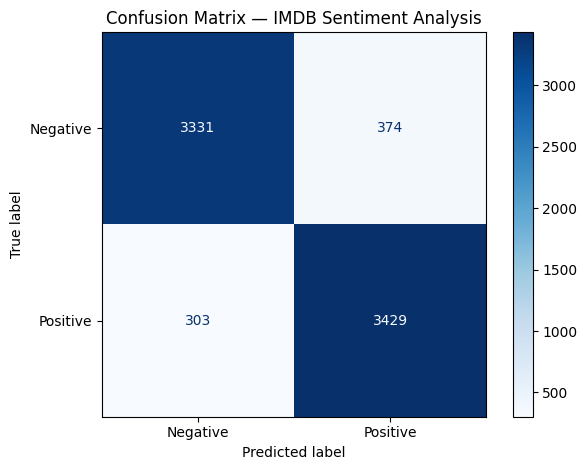

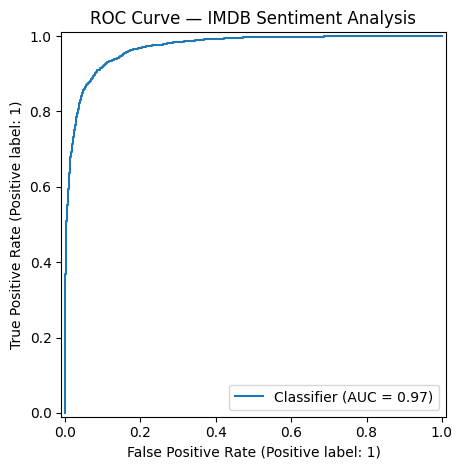


Evaluation complete.


In [9]:
# STEP 9: FINAL TESTING AND MODEL EVALUATION

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# 1. Predict on the unseen test set
y_test_pred = best_model.predict(X_test_tfidf)
y_test_prob = best_model.predict_proba(X_test_tfidf)[:, 1]

# 2. Calculate final evaluation metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)
print("Selected model:", best_model_name)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_roc_auc:.4f}")

# 3. Detailed classification report
print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["Negative", "Positive"],
    digits=4
))

# 4. Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — IMDB Sentiment Analysis")
plt.tight_layout()
plt.show()

# 5. ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("ROC Curve — IMDB Sentiment Analysis")
plt.tight_layout()
plt.show()

# 6. Save final metrics for the project report
test_results = {
    "Model": best_model_name,
    "Test Accuracy": test_accuracy,
    "Test Precision": test_precision,
    "Test Recall": test_recall,
    "Test F1-score": test_f1,
    "Test ROC-AUC": test_roc_auc
}

print("\nEvaluation complete.")

In [10]:
# STEP 10: SAVE THE MODEL AND PREPROCESSING COMPONENT

import os
import joblib

# Create a folder for project artifacts
os.makedirs("/content/imdb_sentiment_project", exist_ok=True)

# Save the trained model
joblib.dump(
    best_model,
    "/content/imdb_sentiment_project/sentiment_model.joblib"
)

# Save the fitted TF-IDF vectorizer
joblib.dump(
    tfidf,
    "/content/imdb_sentiment_project/tfidf_vectorizer.joblib"
)

print("MODEL AND VECTORIZER SAVED")
print("\nSaved files:")

for filename in os.listdir("/content/imdb_sentiment_project"):
    filepath = os.path.join("/content/imdb_sentiment_project", filename)
    print(filename, "-", round(os.path.getsize(filepath) / (1024 * 1024), 2), "MB")

MODEL AND VECTORIZER SAVED

Saved files:
sentiment_model.joblib - 0.23 MB
tfidf_vectorizer.joblib - 1.1 MB


In [11]:
# STEP 11: INTERACTIVE SENTIMENT PREDICTION

import re
import html
import joblib

# Load the saved artifacts
loaded_model = joblib.load(
    "/content/imdb_sentiment_project/sentiment_model.joblib"
)

loaded_tfidf = joblib.load(
    "/content/imdb_sentiment_project/tfidf_vectorizer.joblib"
)

def predict_sentiment(review_text):
    # Apply the same text-cleaning steps used during training
    cleaned_review = html.unescape(str(review_text))
    cleaned_review = re.sub(r"<[^>]+>", " ", cleaned_review)
    cleaned_review = re.sub(
        r"http\S+|www\.\S+", " ", cleaned_review
    )
    cleaned_review = cleaned_review.lower()
    cleaned_review = re.sub(
        r"[^a-z\s']", " ", cleaned_review
    )
    cleaned_review = re.sub(
        r"\s+", " ", cleaned_review
    ).strip()

    if not cleaned_review:
        raise ValueError("Please enter a review containing text.")

    # Convert text into TF-IDF features
    review_vector = loaded_tfidf.transform([cleaned_review])

    # Predict sentiment and probability
    prediction = loaded_model.predict(review_vector)[0]
    probabilities = loaded_model.predict_proba(review_vector)[0]

    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = probabilities[int(prediction)] * 100

    return sentiment, confidence


# Try example reviews
examples = [
    "This movie was fantastic, beautifully acted, and very entertaining.",
    "The film was boring, badly written, and a complete waste of time."
]

for review in examples:
    sentiment, confidence = predict_sentiment(review)
    print("Review:", review)
    print("Predicted sentiment:", sentiment)
    print(f"Model confidence: {confidence:.2f}%")
    print("-" * 60)

# Enter your own review
my_review = input("Enter a movie review: ")

sentiment, confidence = predict_sentiment(my_review)

print("\nPREDICTION RESULT")
print("Sentiment:", sentiment)
print(f"Model confidence: {confidence:.2f}%")

Review: This movie was fantastic, beautifully acted, and very entertaining.
Predicted sentiment: Positive
Model confidence: 98.16%
------------------------------------------------------------
Review: The film was boring, badly written, and a complete waste of time.
Predicted sentiment: Negative
Model confidence: 99.79%
------------------------------------------------------------
Enter a movie review: The movie was amazing! The story was interesting, the actors did a fantastic job, and I really enjoyed watching it. I would definitely recommend it.

PREDICTION RESULT
Sentiment: Positive
Model confidence: 98.41%
